In [15]:
import numpy as np
import matplotlib.pyplot as plt
import ot
from matplotlib import animation

In [16]:
def sersic(n, Ie, re, r):
    bn = 2*n - 1/3
    return Ie * np.exp(-bn*((r/re)**(1/n)-1))

def prob_sersic(n, Ie, re, r):
    return sersic(n, Ie, re, r) * 2*np.pi*r


def spiral(n, Ie, re, Na, w, p, r, phi):
    return sersic(n, Ie, re, r) * (1 + w*np.sin(Na/np.tan(p) * np.log10(r) - Na*phi))

def prob_spiral(n, Ie, re, Na, w, p, r, phi):
    return spiral(n, Ie, re, Na, w, p, r, phi) * r

# Wasserstein interpolation function
def itp(weights, dist1, dist2, N, d, maxIt = 100):
    dists = [dist1, dist2]
    dist_weights = [ot.unif(dist1.shape[0]), ot.unif(dist2.shape[0])]
    k=N
    X_init = np.random.normal(0.0, 1.0, (k, d)) 
    b = np.ones((k,)) / k
    return ot.lp.free_support_barycenter(dists, dist_weights, X_init, b, weights = weights, numItermax= maxIt)

In [17]:
N=3000  # Number of MC samples
d = 2   # Number of dimensions

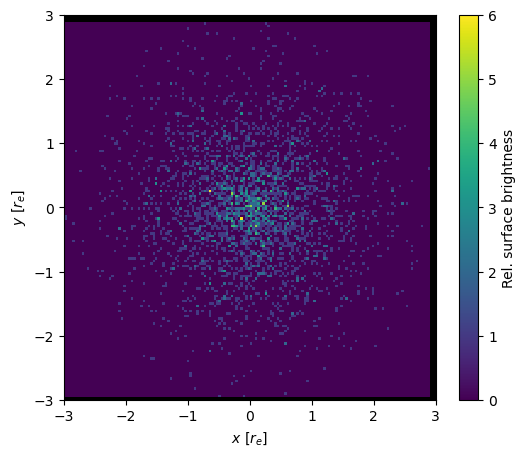

In [41]:
#Disky galaxy

n_sersic = 1; re = 2; Ie = 1; rmax = 3*re
N = 3000

#Draw random samples of radius and probability
r = np.random.uniform(0,rmax,5*N)
pr = np.random.uniform(0,prob_sersic(n_sersic, Ie, re, re),5*N)

#Accept/Reject method
mask = pr <= prob_sersic(n_sersic, Ie, re, r)
r = (r[mask])[:N]

#Spread out in a 2D disk
theta = np.random.uniform(0,2*np.pi,N)
rx = r * np.cos(theta) / re
ry = r * np.sin(theta) / re

plt.figure(figsize=(6,5))

plt.hist2d(rx, ry, bins=150)
plt.gca().set(xlabel='$x\ [r_e]$', ylabel='$y\ [r_e]$', xlim=(-rmax/re,rmax/re), ylim=(-rmax/re,rmax/re), facecolor='k')
plt.colorbar(label='Rel. surface brightness');

#np.savetxt('disk_galaxy.txt', np.c_[rx, ry], fmt='%.3f')

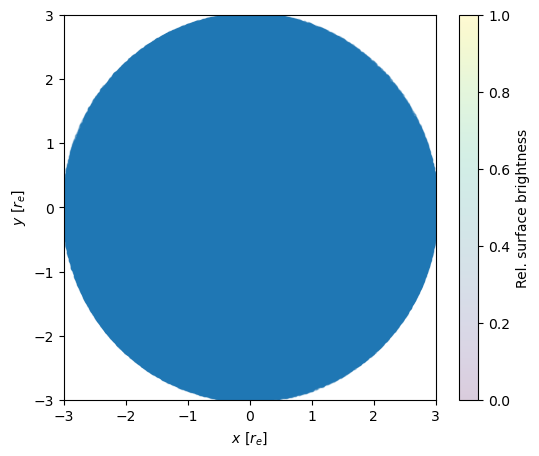

In [ ]:
#Spiral arm galaxy

n_sersic = 1; re = 2; Ie = 1; rmax = 3*re; Na = 3; w = 0.6; p = 10*np.pi/180
N = 5000000

#Now both radius and phi dependence
r = np.random.uniform(0,rmax,5*N)
phi = np.random.uniform(0,2*np.pi,5*N)
pr = np.random.uniform(0,np.max(prob_spiral(n_sersic, Ie, re, Na, w, p, r, phi)),5*N)

mask = pr <= prob_spiral(n_sersic, Ie, re, Na, w, p, r, phi)
r = (r[mask])[:N]
phi = (phi[mask])[:N]

rx = r*np.cos(phi) / re
ry = r*np.sin(phi) / re

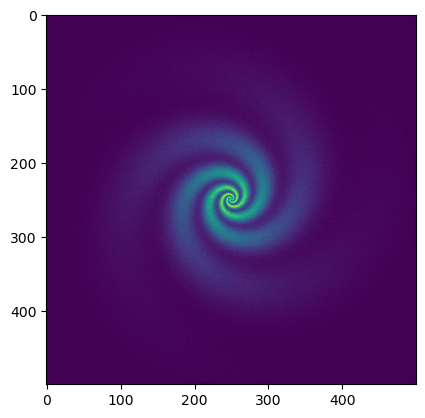

In [59]:
H = np.histogram2d(rx, ry, bins=500)[0]
plt.imshow(H)

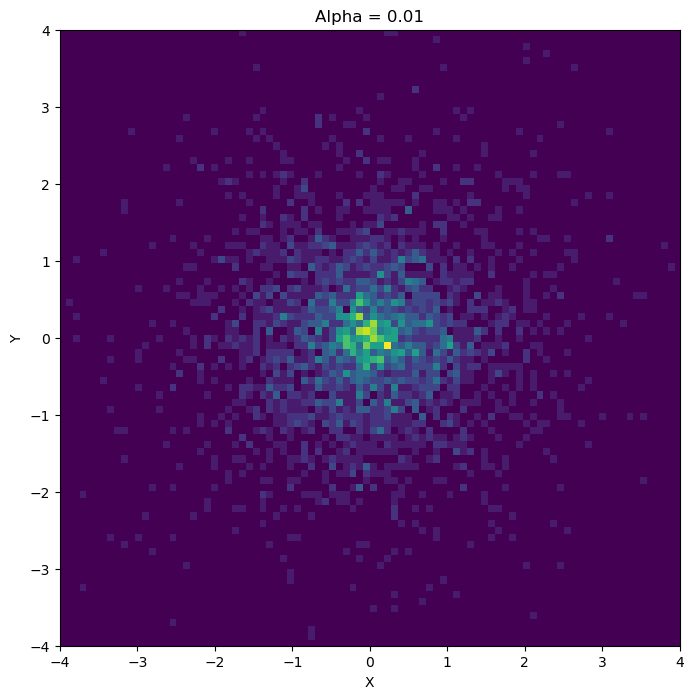

In [ ]:
# Interpolation animation
alphas = np.round(np.linspace(0.01,1,101),3)                #Alphas to use

weights = np.array([1-alphas, alphas])       #Distribution weights

fig = plt.figure(figsize=(8, 8))

def animate(i):
    plt.clf()
    X = itp(weights[:,i], x1, x2, N, d, maxIt = 10000)
    plt.scatter(X[:,0], X[:,1])
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.title("Alpha = "+str(alphas[i]))
    plt.xlim(-4, 4)
    plt.ylim(-4, 4)

anim = animation.FuncAnimation(fig, animate, frames=101, repeat=False)
anim.save("Galaxy_evolution_itp.gif", writer='pillow', fps=10)